In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import json

# Load only first 200k reviews to keep Colab fast
reviews = []
with open('/content/drive/MyDrive/yelp_NLP/yelp_academic_dataset_review.json') as f:
    for i, line in enumerate(f):
        if i >= 200000:
            break
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)
print(df.shape)
print(df.columns.tolist())
df.head()

(200000, 9)
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


/tmp/ipykernel_2307/727383677.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('date')['stars'].resample('M').count().plot(ax=axes[2], color='steelblue')


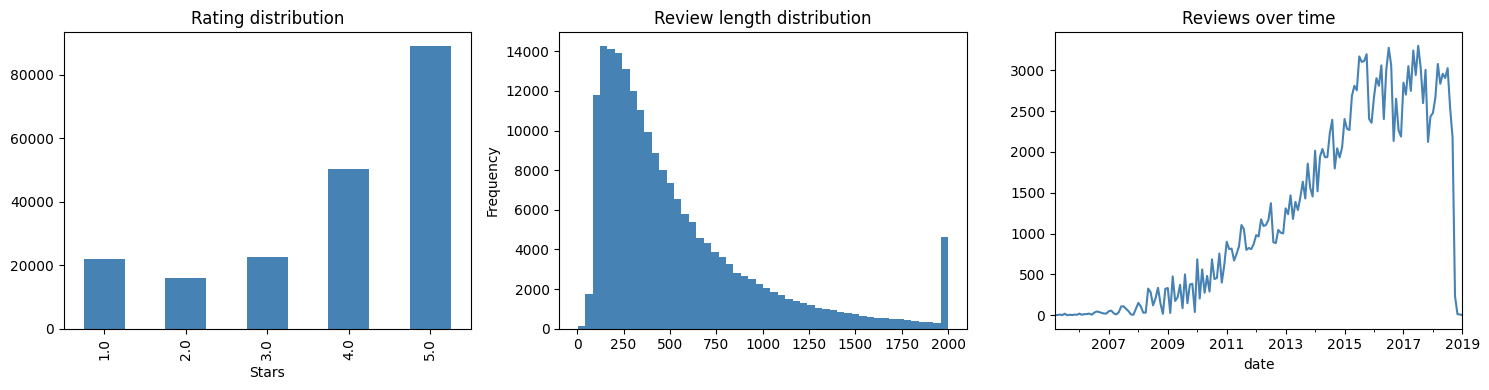

Total reviews: 200,000
Date range: 2005-03-01 17:47:15 to 2019-01-27 15:08:14
Avg review length: 550 chars
Missing values:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
text_length    0
dtype: int64


In [3]:
# Rating distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Star distribution
df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Stars')

# Review length
df['text_length'] = df['text'].str.len()
df['text_length'].clip(upper=2000).plot(kind='hist', bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Review length distribution')

# Reviews over time
df['date'] = pd.to_datetime(df['date'])
df.set_index('date')['stars'].resample('M').count().plot(ax=axes[2], color='steelblue')
axes[2].set_title('Reviews over time')

plt.tight_layout()
plt.show()

print(f"Total reviews: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Avg review length: {df['text_length'].mean():.0f} chars")
print(f"Missing values:\n{df.isnull().sum()}")

In [4]:
# Map star ratings to sentiment
# 1-2 stars = negative, 3 = neutral, 4-5 = positive
def map_sentiment(stars):
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['stars'].apply(map_sentiment)

print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nClass balance:\n{df['sentiment'].value_counts(normalize=True).round(3)}")

Sentiment distribution:
sentiment
positive    139314
negative     38038
neutral      22648
Name: count, dtype: int64

Class balance:
sentiment
positive    0.697
negative    0.190
neutral     0.113
Name: proportion, dtype: float64


In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'[^a-z0-9\s!?.,]', '', text)      # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()           # normalize whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Sanity check
print("Original:", df['text'].iloc[0][:200])
print("\nCleaned:", df['clean_text'].iloc[0][:200])

Original: If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ 

Cleaned: if you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. we have tried it multiple times, because i want to like it! i have been to its other locations in nj a


This code analyzes the most common words used in positive and negative reviews. It filters out common stopwords, counts word frequencies, and displays the top 20 words for each sentiment category.

In [7]:
from collections import Counter
from wordcloud import WordCloud

# Most common words by sentiment
stopwords = set(['the','a','and','is','in','it','of','to','was','for','that',
                 'this','with','on','at','i','my','we','they','be','as','are'])

for sentiment in ['positive', 'negative']:
    subset = df[df['sentiment'] == sentiment]['clean_text']
    words = ' '.join(subset.sample(5000, random_state=42)).split()
    words = [w for w in words if w not in stopwords and len(w) > 3]
    freq = Counter(words).most_common(20)
    print(f"\nTop 20 words in {sentiment} reviews:")
    print(freq)


Top 20 words in positive reviews:
[('have', 2773), ('were', 2379), ('great', 2278), ('very', 2012), ('place', 1840), ('food', 1774), ('good', 1626), ('their', 1351), ('there', 1298), ('like', 1258), ('from', 1248), ('just', 1223), ('here', 1164), ('which', 1119), ('really', 1081), ('will', 1078), ('would', 1038), ('service', 1026), ('best', 1007), ('when', 1004)]

Top 20 words in negative reviews:
[('were', 4216), ('have', 3816), ('food', 2524), ('there', 2470), ('just', 2394), ('when', 2308), ('like', 2154), ('would', 2154), ('place', 1880), ('very', 1862), ('from', 1835), ('about', 1723), ('their', 1573), ('service', 1515), ('time', 1511), ('what', 1491), ('been', 1481), ('will', 1468), ('after', 1443), ('because', 1426)]


Save cleaned random balanced 50k reviews into a csv

In [8]:
# Save a balanced sample for modeling (50k reviews, balanced classes)
balanced = pd.concat([
    df[df['sentiment'] == 'positive'].sample(20000, random_state=42),
    df[df['sentiment'] == 'negative'].sample(15000, random_state=42),
    df[df['sentiment'] == 'neutral'].sample(15000, random_state=42)
])

balanced = balanced.sample(frac=1, random_state=42).reset_index(drop=True)
balanced[['review_id', 'stars', 'sentiment', 'text', 'clean_text', 'date', 'text_length']].to_csv(
    '/content/drive/MyDrive/yelp_NLP/reviews_balanced_50k.csv', index=False
)

print(f"Saved {len(balanced):,} reviews")
print(balanced['sentiment'].value_counts())

Saved 50,000 reviews
sentiment
positive    20000
negative    15000
neutral     15000
Name: count, dtype: int64


In [9]:
# Exploring engagement signals — useful/funny/cool votes can proxy for review quality
print("Reviews with useful votes > 0:", (df['useful'] > 0).sum())
print("Reviews with useful votes > 5:", (df['useful'] > 5).sum())
print("\nTop 3 most useful reviews:")
df.nlargest(3, 'useful')[['stars', 'useful', 'text']].apply(
    lambda x: print(f"\nStars: {x['stars']} | Useful votes: {x['useful']}\n{x['text'][:200]}"), axis=1
);

Reviews with useful votes > 0: 80564
Reviews with useful votes > 5: 5017

Top 3 most useful reviews:

Stars: 1.0 | Useful votes: 320
I would not recommend anyone to live here.  They market this building as a luxury building, but it is far from it.  There are major HVAC issues where you will be freezing in the winter and sweating in

Stars: 1.0 | Useful votes: 171
Update 8/9/14: There are now swarms of children running around the building now.  They are out UNSUPERVISED at all hours of the evening (I've seen them out as late as midnight).  They are running on m

Stars: 5.0 | Useful votes: 91
fast service and superb skills. this is by far the best locksmith I've used in ages!


/tmp/ipykernel_2307/1724577723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='text_length',


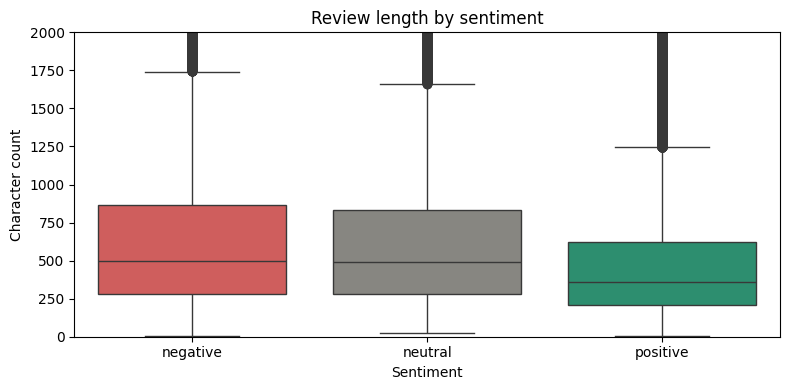

              count   mean    std   min    25%    50%    75%     max
sentiment                                                           
negative    38038.0  680.0  608.0   3.0  282.0  500.0  866.0  5000.0
neutral     22648.0  650.0  555.0  25.0  280.0  491.0  833.0  5000.0
positive   139314.0  497.0  454.0   3.0  208.0  358.0  623.0  5000.0


In [10]:
# Understanding if review length correlates with sentiment — useful for feature engineering later
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='sentiment', y='text_length',
            order=['negative', 'neutral', 'positive'],
            palette={'negative':'#E24B4A', 'neutral':'#888780', 'positive':'#1D9E75'})
plt.ylim(0, 2000)
plt.title('Review length by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Character count')
plt.tight_layout()
plt.show()

print(df.groupby('sentiment')['text_length'].describe().round(0))

So after sentiment analysis, it is clear with this boxplot that negative/neutral reviews are slightly longer than positive reviews

/tmp/ipykernel_2307/3536093171.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  monthly = df.set_index('date').groupby([pd.Grouper(freq='Y'), 'sentiment']).size().unstack(fill_value=0)


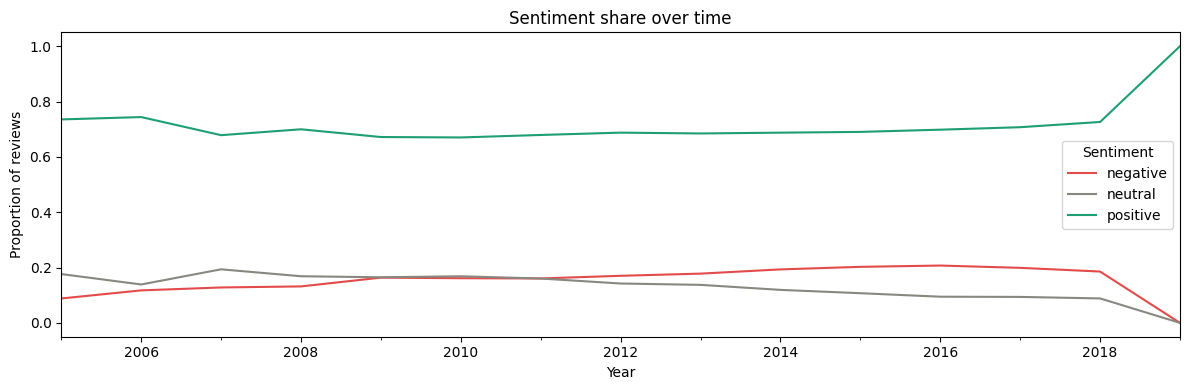

In [11]:
# Temporal analysis — checking if review sentiment has shifted over the years
monthly = df.set_index('date').groupby([pd.Grouper(freq='Y'), 'sentiment']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)

monthly_pct.plot(figsize=(12, 4),
                 color={'negative':'#E24B4A', 'neutral':'#888780', 'positive':'#1D9E75'})
plt.title('Sentiment share over time')
plt.ylabel('Proportion of reviews')
plt.xlabel('Year')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [12]:
# Summary stats to include in the README — snapshot of the dataset we are working with
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total reviews loaded:     {len(df):>10,}")
print(f"Date range:               {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Avg review length:        {df['text_length'].mean():>10.0f} chars")
print(f"Median review length:     {df['text_length'].median():>10.0f} chars")
print(f"\nSentiment breakdown:")
for s, n in df['sentiment'].value_counts().items():
    print(f"  {s:<12} {n:>8,}  ({n/len(df)*100:.1f}%)")
print(f"\nBalanced sample saved:    50,000 reviews")

DATASET SUMMARY
Total reviews loaded:        200,000
Date range:               2005-03-01 to 2019-01-27
Avg review length:               550 chars
Median review length:            395 chars

Sentiment breakdown:
  positive      139,314  (69.7%)
  negative       38,038  (19.0%)
  neutral        22,648  (11.3%)

Balanced sample saved:    50,000 reviews
